In [15]:
import os
import re
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, QED, Lipinski
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import random
from tqdm import tqdm

In [20]:
import os
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, QED, Lipinski
import pandas as pd

def calculate_tpsa(smiles_list):
    tpsa_values = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles.strip())
        if mol is not None:
            tpsa = rdMolDescriptors.CalcTPSA(mol)
            tpsa_values.append(tpsa)
        else:
            tpsa_values.append(None)
    return tpsa_values

def get_max_ring_size(mol):
    ring_sizes = [len(r) for r in mol.GetRingInfo().AtomRings()]
    if len(ring_sizes) == 0:
        return 0
    return max(ring_sizes)

def calc_props(input):
    if type(input) is str:
        mol = Chem.MolFromSmiles(input)
    else:
        mol = input
    fraction_csp3 = Lipinski.FractionCSP3(mol)
    heavy_atoms = Lipinski.HeavyAtomCount(mol)
    hbond_donor = Lipinski.NumHDonors(mol)
    hbond_acceptor = Lipinski.NumHAcceptors(mol)
    num_ring_aliphatic = Lipinski.NumAliphaticRings(mol)
    num_ring_aromatic = Lipinski.NumAromaticRings(mol)
    num_rotatable_bond = Lipinski.NumRotatableBonds(mol)
    try:
        qed_prop = QED.properties(mol)
        qed_default = QED.default(mol)
    except:
        return None
    hetero_prop = 0.0
    if heavy_atoms != 0:
        hetero_prop = Lipinski.NumHeteroatoms(mol) / heavy_atoms
    max_ring_size = get_max_ring_size(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    return [fraction_csp3, heavy_atoms, hbond_donor, hbond_acceptor, num_ring_aliphatic, num_ring_aromatic, 
            num_rotatable_bond, qed_default, qed_prop.MW, qed_prop.ALOGP, qed_prop.PSA, qed_prop.ALERTS, 
            hetero_prop, max_ring_size, tpsa]

def check_validity(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

def calculate_and_save_properties(smiles_list, dataset_name):
    properties = []
    failed_smiles = []
    for smiles in tqdm(smiles_list):
        if check_validity(smiles.strip()):
            props = calc_props(smiles.strip())
            if props is not None:
                properties.append([smiles.strip()] + props + [dataset_name])
            else:
                failed_smiles.append(smiles.strip())
    
    return properties, failed_smiles

# Define the paths to the specific files
file_paths = {
    'chembl_random_smiles.txt': 'ChEMBL_sample',
    '8b-lora32/samples/temp1.0.txt': 'Llama-FT(T=1.0)',
}

# Initialize an empty list to collect all the data
all_properties = []

# Process each file and append results
for file_path, dataset_name in file_paths.items():
    with open(file_path, 'r') as file:
        smiles = [line.strip() for line in file]
        np.random.seed(42)
        indices = np.random.choice(len(smiles), 20000, replace=False)
        smiles_list = [smiles[i] for i in indices if Chem.MolFromSmiles(smiles[i]) is not None]
        smiles_list = smiles_list[:10000]

    
    properties, failed_smiles = calculate_and_save_properties(smiles_list, dataset_name)
    all_properties.extend(properties)

# Convert the collected data into a DataFrame and save as a single CSV
columns = ["SMILES", "fraction_csp3", "heavy_atoms", "hbond_donor", "hbond_acceptor", 
           "num_ring_aliphatic", "num_ring_aromatic", "num_rotatable_bond", "qed_default", 
           "MW", "ALOGP", "PSA", "ALERTS", "hetero_prop", "max_ring_size", "tpsa", "dataset"]

df = pd.DataFrame(all_properties, columns=columns)
df.to_csv('combined_properties.csv', index=False)

# Optionally save failed SMILES
with open('failed_smiles.txt', 'w') as file:
    file.write('\n'.join([row[0] for row in all_properties if row[1] is None]))


100%|██████████| 10000/10000 [00:32<00:00, 311.14it/s]


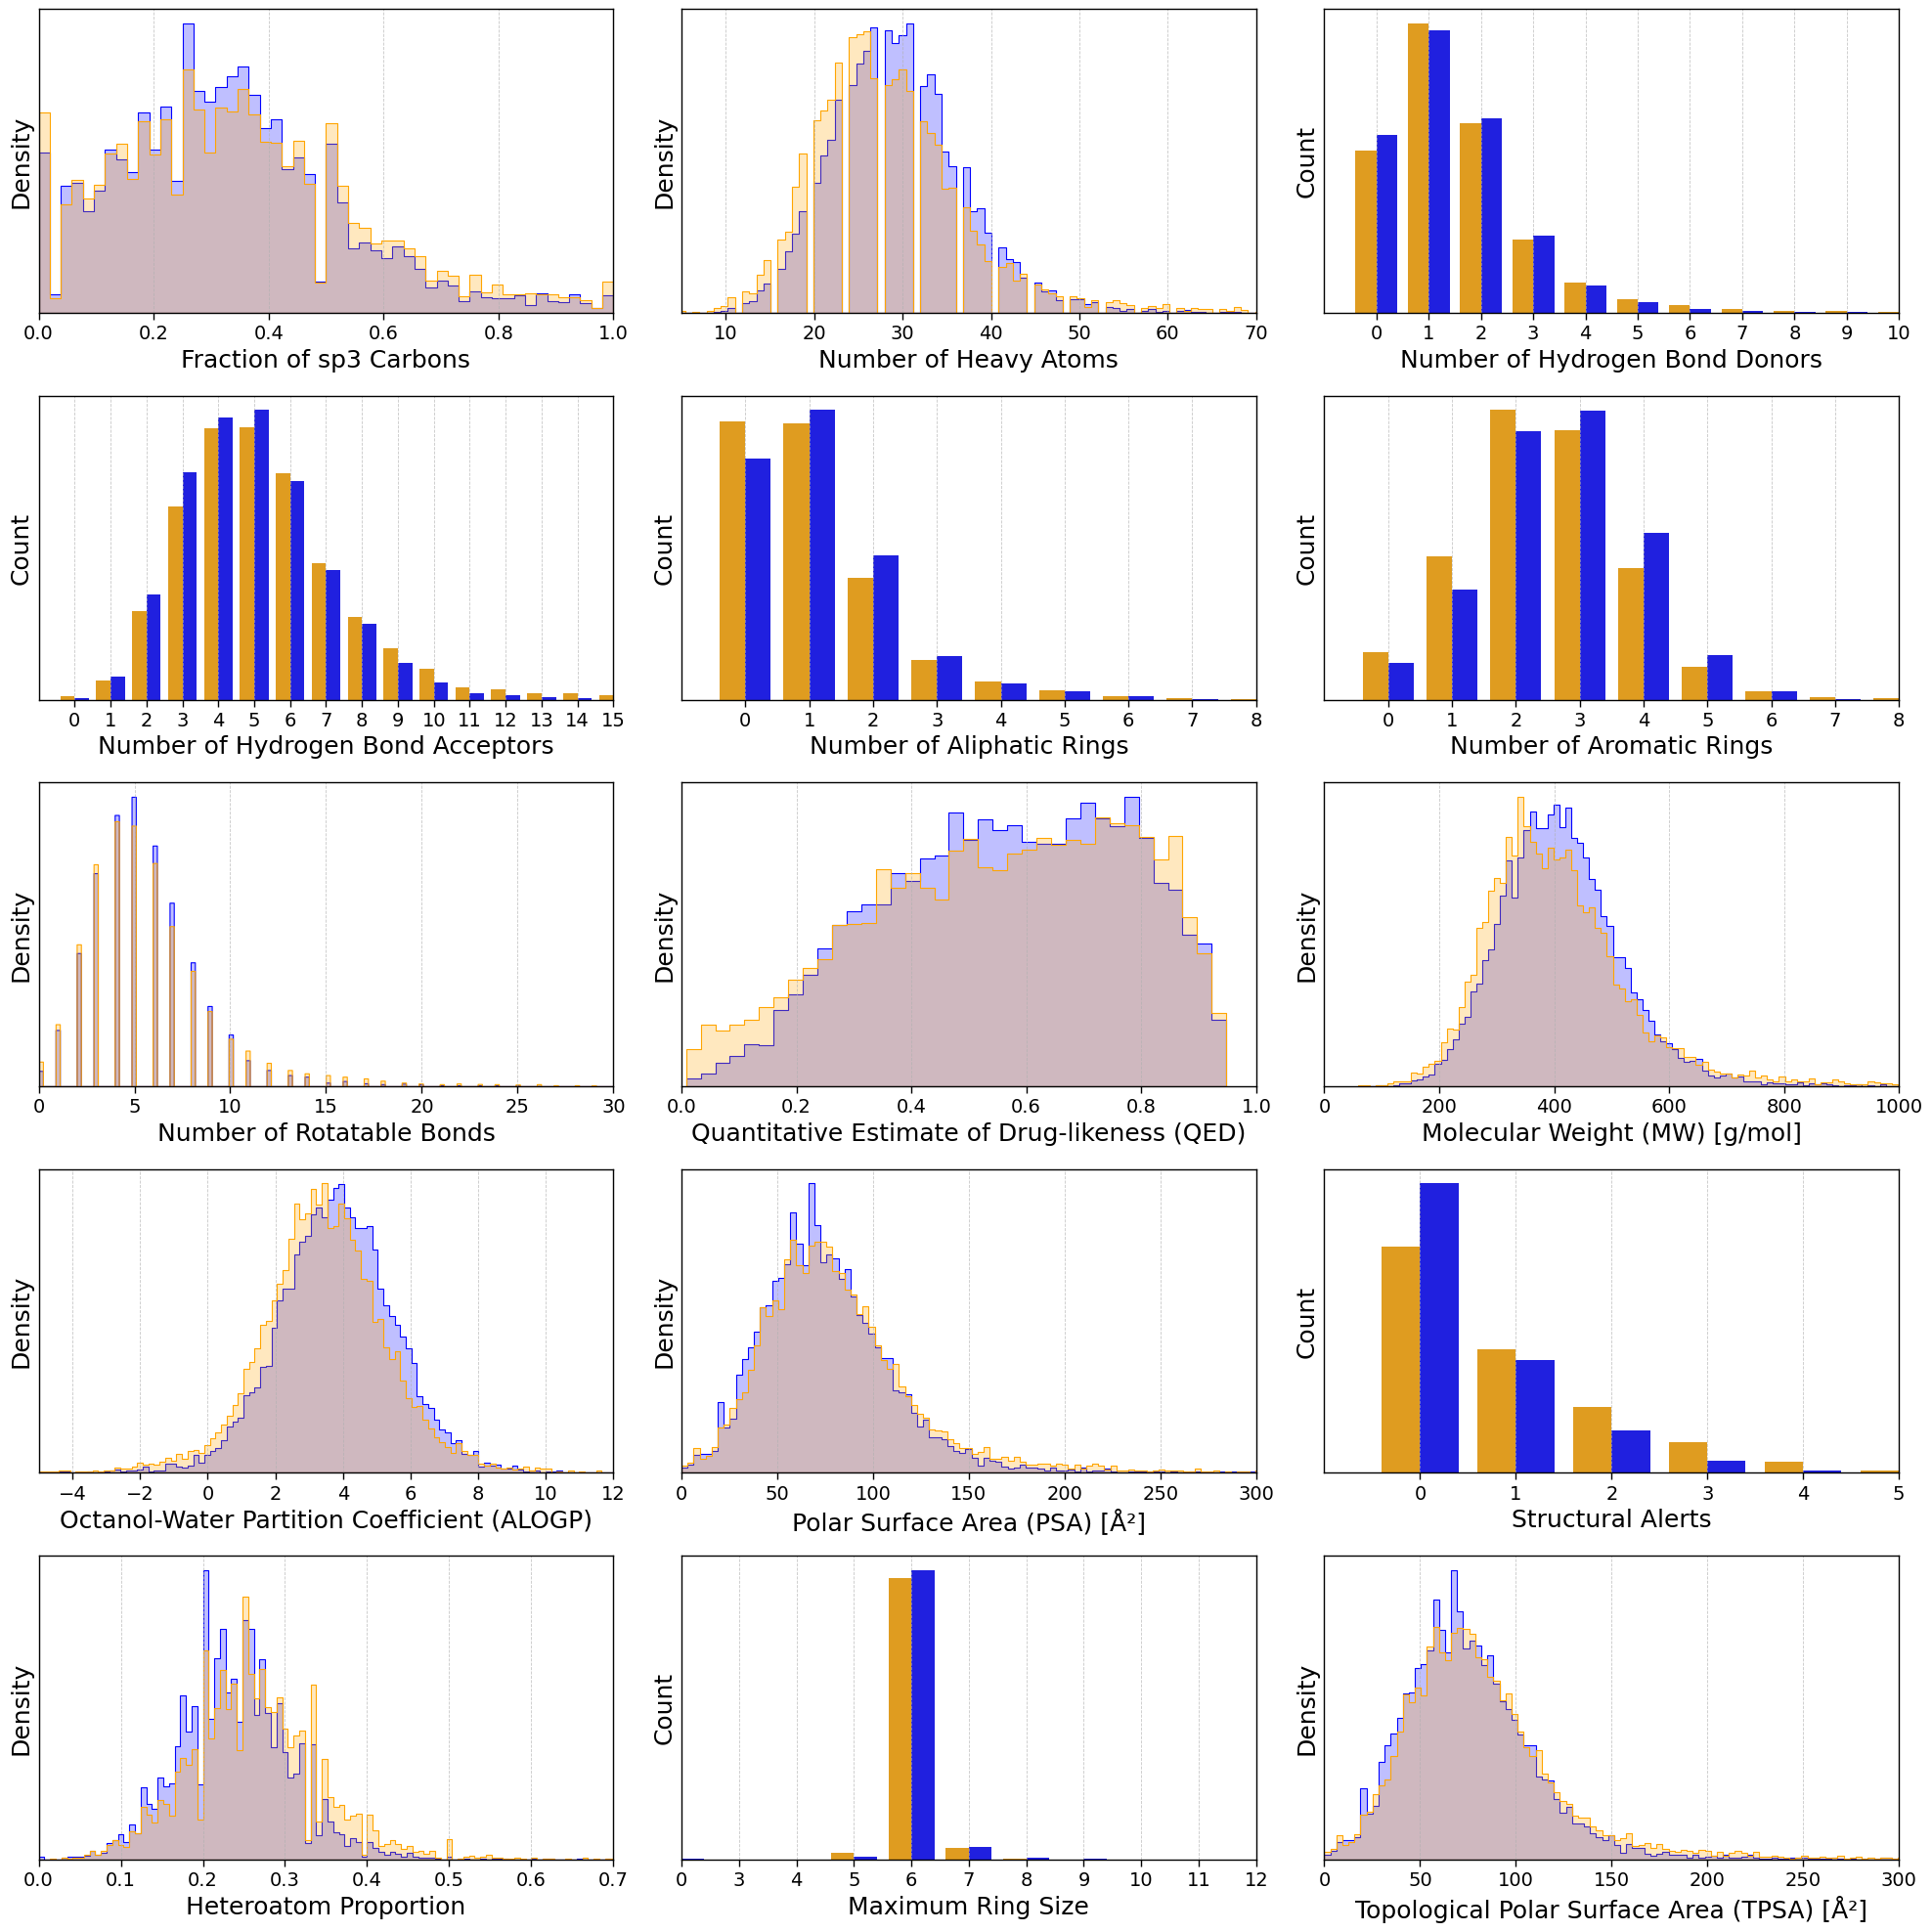

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the combined CSV file
df = pd.read_csv('combined_properties.csv')

# Filter the dataframe to keep only the ChEMBL and 0.6 temp datasets
df_filtered = df[df['dataset'].isin(['ChEMBL_sample', 'Llama-FT(T=1.0)'])]

# Define the x-axis limits for each property
x_limits = {
    'fraction_csp3': (0, 1),
    'heavy_atoms': (5, 70),
    'hbond_donor': (-1, 10),
    'hbond_acceptor': (-1, 15),
    'num_ring_aliphatic': (-1, 8),
    'num_ring_aromatic': (-1, 8),
    'num_rotatable_bond': (0, 30),
    'qed_default': (0, 1),
    'MW': (0, 1000),
    'ALOGP': (-5, 12),
    'PSA': (0, 300),
    'ALERTS': (-1, 5),
    'hetero_prop': (0, 0.7),
    'max_ring_size': (0, 10),
    'tpsa': (0, 300)
}

# Define the list of properties to plot
properties = list(x_limits.keys())

# Set properties to use bar plots for
bar_plot_properties = [
    'hbond_donor', 
    'hbond_acceptor', 
    'num_ring_aliphatic', 
    'num_ring_aromatic',
    'ALERTS', 
    'max_ring_size'
]

# Set up a dictionary for more descriptive titles
property_titles = {
    'fraction_csp3': 'Fraction of sp3 Carbons',
    'heavy_atoms': 'Number of Heavy Atoms',
    'hbond_donor': 'Number of Hydrogen Bond Donors',
    'hbond_acceptor': 'Number of Hydrogen Bond Acceptors',
    'num_ring_aliphatic': 'Number of Aliphatic Rings',
    'num_ring_aromatic': 'Number of Aromatic Rings',
    'num_rotatable_bond': 'Number of Rotatable Bonds',
    'qed_default': 'Quantitative Estimate of Drug-likeness (QED)',
    'MW': 'Molecular Weight (MW) [g/mol]',  # Add units for MW
    'ALOGP': 'Octanol-Water Partition Coefficient (ALOGP)',
    'PSA': 'Polar Surface Area (PSA) [Å²]',  # Add units for PSA
    'ALERTS': 'Structural Alerts',
    'hetero_prop': 'Heteroatom Proportion',
    'max_ring_size': 'Maximum Ring Size',
    'tpsa': 'Topological Polar Surface Area (TPSA) [Å²]'  # Add units for TPSA
}

# Set a colorblind-friendly palette and seaborn style
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)  # Paper context with scaled fonts for publication

# Custom colorblind-friendly palette
custom_palette = {
    'ChEMBL_sample': 'orange',  # Manually set ChEMBL data to orange
    'Llama-FT(T=1.0)': 'blue'  # Set Llama-FT(T=0.6) to blue for distinction
}

# Set up the figure and axes for the subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 20))
axes = axes.flatten()

# Iterate through each property and create a subplot
for i, prop in enumerate(properties):
    ax = axes[i]
    
    if prop in bar_plot_properties:
        # Create bar plot for specified properties
        sns.countplot(data=df_filtered, x=prop, hue='dataset', palette=custom_palette, ax=ax)
    else:
        # Create the histogram plot for the remaining properties
        sns.histplot(data=df_filtered, x=prop, hue='dataset', element='step', stat='density', common_norm=False, ax=ax, palette=custom_palette)
    
    # Set the x-axis limit
    ax.set_xlim(x_limits[prop])
    
    # Set the title using the descriptive titles from the dictionary
    ax.set_title('')
    
    # Add labels
    ax.set_xlabel(property_titles.get(prop, prop), fontsize=18)
    ax.set_ylabel('Density' if prop not in bar_plot_properties else 'Count', fontsize=18)
    
    # Improve the tick label visibility
    ax.tick_params(axis='x', which='major', labelsize=14)
    ax.set_yticks([])
    
    # Add grid for better readability
    ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    # Remove legend from the subplot
    if ax.legend_:
        ax.legend_.remove()

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Save the figure for use in publications
plt.savefig('property_comparison_plot.png', dpi=600, bbox_inches='tight')

# Show the plots
plt.show()

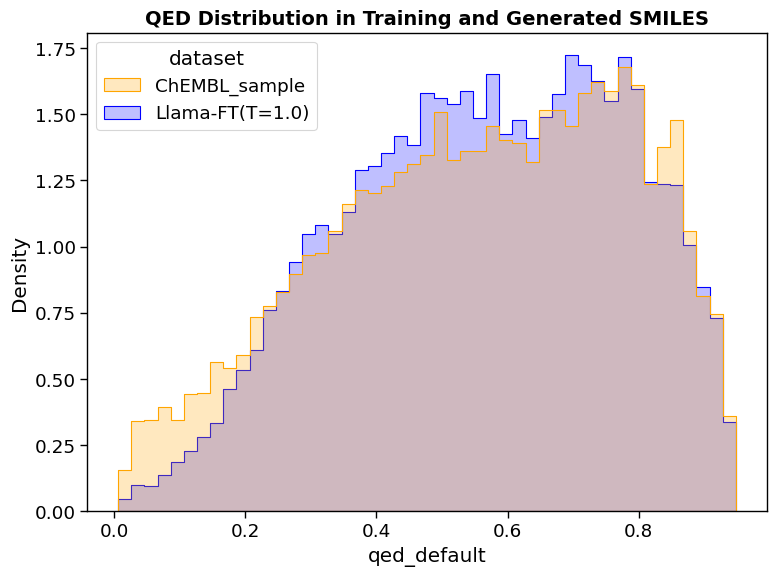

In [4]:
# Set a colorblind-friendly palette and seaborn style
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)  # Paper context with scaled fonts for publication

# Custom colorblind-friendly palette
custom_palette = {
    'ChEMBL_sample': 'orange',  # Manually set ChEMBL data to orange
    'Llama-FT(T=1.0)': 'blue'
}

# Set up the figure and axes for the subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))



# Create the histogram plot for the remaining properties
sns.histplot(data=df_filtered, x='qed_default', hue='dataset', element='step', stat='density', common_norm=False, ax=axes, palette=custom_palette)

# Set the x-axis limit
ax.set_xlim(x_limits[prop])

# Set the title using the descriptive titles from the dictionary
plt.title('QED Distribution in Training and Generated SMILES', 
              fontsize=14, fontweight='bold')

# Add labels
ax.set_xlabel('QED Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)

# Improve the tick label visibility
ax.tick_params(axis='both', which='major', labelsize=10)

# Add grid for better readability
ax.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)

# Remove legend from the subplot
if ax.legend_:
    ax.legend_.remove()

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Save the figure for use in publications
plt.savefig('qed_comparison_plot.png', dpi=600, bbox_inches='tight')

# Show the plots
plt.show()

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import DataStructs
import umap
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def smiles_to_fingerprint(smiles, radius=2, n_bits=2048):
    """Convert SMILES to Morgan fingerprint"""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    except:
        return None

def load_smiles_from_file(filepath, max_samples=None):
    """Load SMILES strings from text file"""
    with open(filepath, 'r') as f:
        smiles = [line.strip() for line in f if line.strip()]
    
    if max_samples and len(smiles) > max_samples:
        # Random sampling for large datasets
        np.random.seed(42)
        indices = np.random.choice(len(smiles), max_samples, replace=False)
        smiles = [smiles[i] for i in indices]
    
    return smiles

def compute_fingerprints_batch(smiles_list, batch_size=1000, max_samples=None):
    """Compute fingerprints in batches with progress bar"""
    fingerprints = []
    valid_indices = []
    
    print(f"Computing fingerprints for {len(smiles_list)} molecules...")
    
    for i in tqdm(range(0, len(smiles_list), batch_size)):
        batch = smiles_list[i:i+batch_size]
        for j, smiles in enumerate(batch):
            fp = smiles_to_fingerprint(smiles)
            if fp is not None:
                fingerprints.append(fp)
                valid_indices.append(i + j)
            if len(fingerprints) >= max_samples:
                break
    
    return np.array(fingerprints)[:max_samples], valid_indices[:max_samples]

def create_smiles_umap(generated_file, training_file, 
                         max_training_samples=50000,
                         max_generated_samples=50000,
                         n_neighbors=30, min_dist=0.1, 
                         ):
    """
    Create UMAP visualization comparing generated vs training SMILES
    
    Parameters:
    -----------
    generated_file : str
        Path to text file with generated SMILES (one per line)
    training_file : str  
        Path to text file with training SMILES (one per line)
    max_training_samples : int
        Maximum number of training samples to use (for efficiency)
    n_neighbors : int
        UMAP n_neighbors parameter
    min_dist : float
        UMAP min_dist parameter
    figsize : tuple
        Figure size for plot
    save_path : str
        Path to save the plot (optional)
    """
    
    # Load SMILES
    print("Loading SMILES files...")
    generated_smiles = load_smiles_from_file(generated_file, max_generated_samples*2)
    training_smiles = load_smiles_from_file(training_file, max_training_samples*2)
    
    print(f"Loaded {len(generated_smiles)} generated molecules")
    print(f"Loaded {len(training_smiles)} training molecules")
    
    # Compute fingerprints
    print("\nComputing fingerprints...")
    gen_fps, gen_valid_idx = compute_fingerprints_batch(generated_smiles, max_samples=max_generated_samples)
    train_fps, train_valid_idx = compute_fingerprints_batch(training_smiles, max_samples=max_training_samples)
    
    print(f"Valid fingerprints: {len(gen_fps)} generated, {len(train_fps)} training")
    
    if len(gen_fps) == 0 or len(train_fps) == 0:
        raise ValueError("No valid molecules found in one or both datasets")
    
    # Combine fingerprints
    all_fps = np.vstack([train_fps, gen_fps])
    labels = np.array(['Training'] * len(train_fps) + ['Generated'] * len(gen_fps))
    
    print(f"\nTotal molecules for UMAP: {len(all_fps)}")
    
    # Fit UMAP
    print("Fitting UMAP...")
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=42,
        n_jobs=-1  # Use all available cores
    )
    
    embedding = reducer.fit_transform(all_fps)
    return embedding, labels, reducer

In [6]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

generated_file = "8b-lora32/samples/temp1.0.txt"
training_file = "chembl_random_smiles.txt"

embedding, labels, reducer = create_smiles_umap(
    generated_file=generated_file,
    training_file=training_file,
    max_training_samples=10000,
    max_generated_samples=10000,
    n_neighbors=15,
    min_dist=0.1
)

Loading SMILES files...
Loaded 20000 generated molecules
Loaded 20000 training molecules

Computing fingerprints...
Computing fingerprints for 20000 molecules...


100%|██████████| 20/20 [00:13<00:00,  1.46it/s]


Computing fingerprints for 20000 molecules...


100%|██████████| 20/20 [00:13<00:00,  1.48it/s]


Valid fingerprints: 10000 generated, 10000 training

Total molecules for UMAP: 20000
Fitting UMAP...


In [7]:
def visualize_smiles_umap(embedding, labels, figsize=(12, 10), save_path=None):
    # Create visualization
    print("Creating visualization...")
    plt.figure(figsize=figsize)
    
    # Plot training data first (background)
    train_mask = labels == 'Training'
    plt.scatter(embedding[train_mask, 0], embedding[train_mask, 1], 
               c='orange', alpha=0.9, s=1, label=f'Training (n={np.sum(train_mask)})')
    
    # Plot generated data on top (foreground)
    gen_mask = labels == 'Generated'
    plt.scatter(embedding[gen_mask, 0], embedding[gen_mask, 1], 
               c='blue', alpha=0.7, s=1, label=f'Generated (n={np.sum(gen_mask)})')
    
    plt.xlabel('UMAP 1', fontsize=12)
    plt.ylabel('UMAP 2', fontsize=12)
    plt.title('Chemical Space: Generated vs Training Molecules\n(UMAP of Morgan Fingerprints)', 
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Remove ticks for cleaner look
    plt.xticks([])
    plt.yticks([])
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

Creating visualization...
Plot saved to full_umap_comparison.png


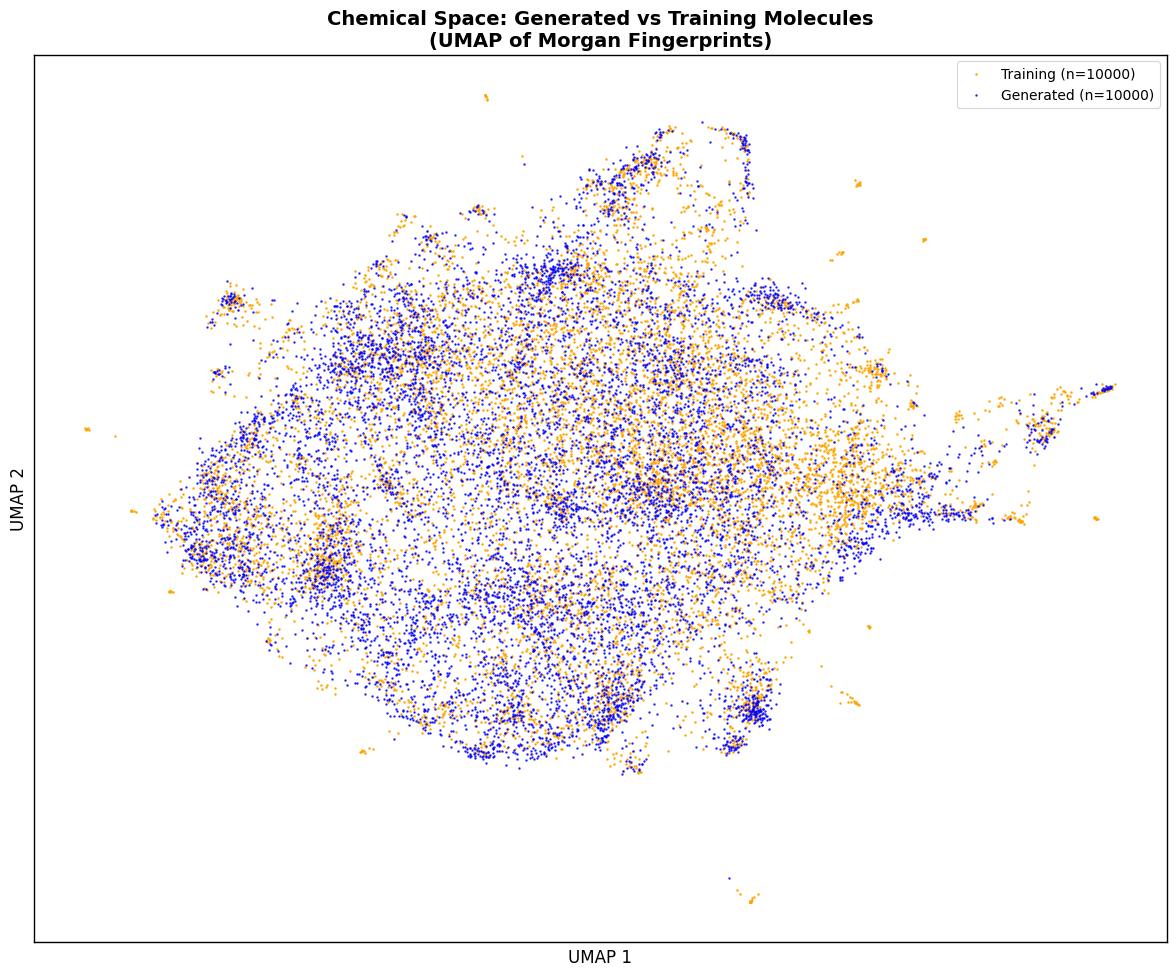

In [8]:
results = visualize_smiles_umap(
    embedding,
    labels,
    save_path="full_umap_comparison.png"
)

In [9]:
def remove_outliers_iqr(embedding, labels, iqr_factor=1.5):
    """Remove outliers using IQR method on both UMAP dimensions"""
    # Calculate IQR for both dimensions
    q75_x, q25_x = np.percentile(embedding[:, 0], [75, 25])
    q75_y, q25_y = np.percentile(embedding[:, 1], [75, 25])
    
    iqr_x = q75_x - q25_x
    iqr_y = q75_y - q25_y
    
    # Define outlier bounds
    lower_x = q25_x - (iqr_factor * iqr_x)
    upper_x = q75_x + (iqr_factor * iqr_x)
    lower_y = q25_y - (iqr_factor * iqr_y) 
    upper_y = q75_y + (iqr_factor * iqr_y)
    
    # Keep only non-outliers
    mask = ((embedding[:, 0] >= lower_x) & (embedding[:, 0] <= upper_x) & 
            (embedding[:, 1] >= lower_y) & (embedding[:, 1] <= upper_y))
    
    return embedding[mask], labels[mask], mask

# Then in your visualization function, after fitting UMAP:
embedding_clean, labels_clean, keep_mask = remove_outliers_iqr(embedding, labels, iqr_factor=2.0)
n_outliers_removed = len(embedding) - len(embedding_clean)
print(f"Removed {n_outliers_removed} outliers ({n_outliers_removed/len(embedding)*100:.1f}%)")

Removed 0 outliers (0.0%)


Creating visualization...
Plot saved to smiles_umap_comparison.png


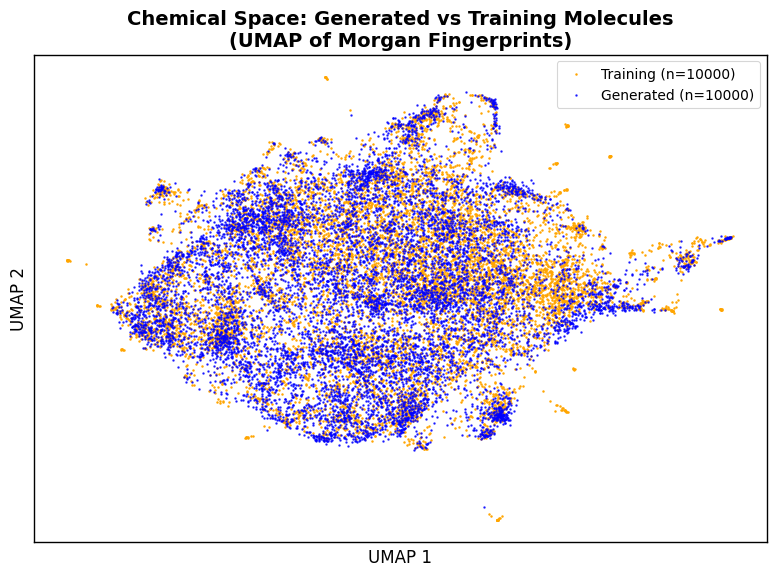

In [10]:
results = visualize_smiles_umap(
    embedding_clean,
    labels_clean,
    figsize=(8,6),
    save_path="smiles_umap_comparison.png"
)

In [11]:
# Set a colorblind-friendly palette and seaborn style
sns.set_palette("colorblind")
sns.set_context("paper", font_scale=1.5)  # Paper context with scaled fonts for publication

def create_combined_plots(df_filtered, embedding, labels, x_limits, prop='qed_default', save_path='combined_plots.png'):
    """
    Create side-by-side plots: QED distribution histogram and UMAP visualization
    
    Parameters:
    - df_filtered: DataFrame for histogram plot
    - embedding: UMAP embedding array
    - labels: Labels for UMAP plot ('Training' or 'Generated')
    - x_limits: Dictionary with x-axis limits
    - prop: Property name for x_limits lookup
    - save_path: Path to save the combined figure
    """
    
    # Custom colorblind-friendly palette for histogram
    custom_palette = {
        'ChEMBL_sample': 'orange',  # Manually set ChEMBL data to orange
        'Llama-FT(T=1.0)': 'blue'
    }
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    
    # ========== LEFT PLOT: QED Distribution Histogram ==========
    sns.histplot(data=df_filtered, x='qed_default', hue='dataset', 
                element='step', stat='density', common_norm=False, 
                ax=ax1, palette=custom_palette)
    y_max = ax1.get_ylim()[1]
    
    from scipy import stats
    
    datasets = df_filtered['dataset'].unique()
    colors = [custom_palette[dataset] for dataset in datasets]
    
    for dataset, color in zip(datasets, colors):
        # Get data for this dataset
        data_subset = df_filtered[df_filtered['dataset'] == dataset]['qed_default']
        
        # Calculate KDE
        kde = stats.gaussian_kde(data_subset)
        x_range = np.linspace(data_subset.min(), data_subset.max(), 200)
        kde_values = kde(x_range)
        
        # Scale KDE to run along top of histogram (scale to ~80% of max height)
        kde_scaled = kde_values / kde_values.max() * y_max * 0.9
        
        # Plot scaled KDE
        ax1.plot(x_range, kde_scaled, color=color, linewidth=2.5, 
                linestyle='-', alpha=0.9, label=f'{dataset} KDE')
    
    # Set the x-axis limit
    ax1.set_xlim(x_limits[prop])
    
    # Set the title
    ax1.set_title('QED Distribution in Training and Generated SMILES', 
                  fontsize=14, fontweight='bold')
    
    # Add labels
    ax1.set_xlabel('QED Score', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    
    # Improve the tick label visibility
    ax1.tick_params(axis='both', which='major', labelsize=10)
    
    # Add grid for better readability
    ax1.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)
    
    # Keep legend for the first plot
    # ax1.legend() will be automatically created by seaborn
    
    # ========== RIGHT PLOT: UMAP Visualization ==========
    # Plot training data first (background)
    train_mask = labels == 'Training'
    ax2.scatter(embedding[train_mask, 0], embedding[train_mask, 1], 
               c='tab:orange', alpha=0.7, s=0.1, label=f'Training')
    
    # Plot generated data on top (foreground)
    gen_mask = labels == 'Generated'
    ax2.scatter(embedding[gen_mask, 0], embedding[gen_mask, 1], 
               c='blue', alpha=0.7, s=1, label=f'Generated')
    
    ax2.set_xlabel('UMAP 1', fontsize=12)
    ax2.set_ylabel('UMAP 2', fontsize=12)
    ax2.set_title('Chemical Space: Generated vs Training Molecules\n(UMAP of Morgan Fingerprints)', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Remove ticks for cleaner look
    ax2.set_xticks([])
    ax2.set_yticks([])
    
    # Adjust the layout to prevent overlapping
    plt.tight_layout()
    
    # Save the figure for use in publications
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Combined plot saved to {save_path}")
    
    # Show the plots
    plt.show()
    
    return fig, (ax1, ax2)

Combined plot saved to figure-2.png


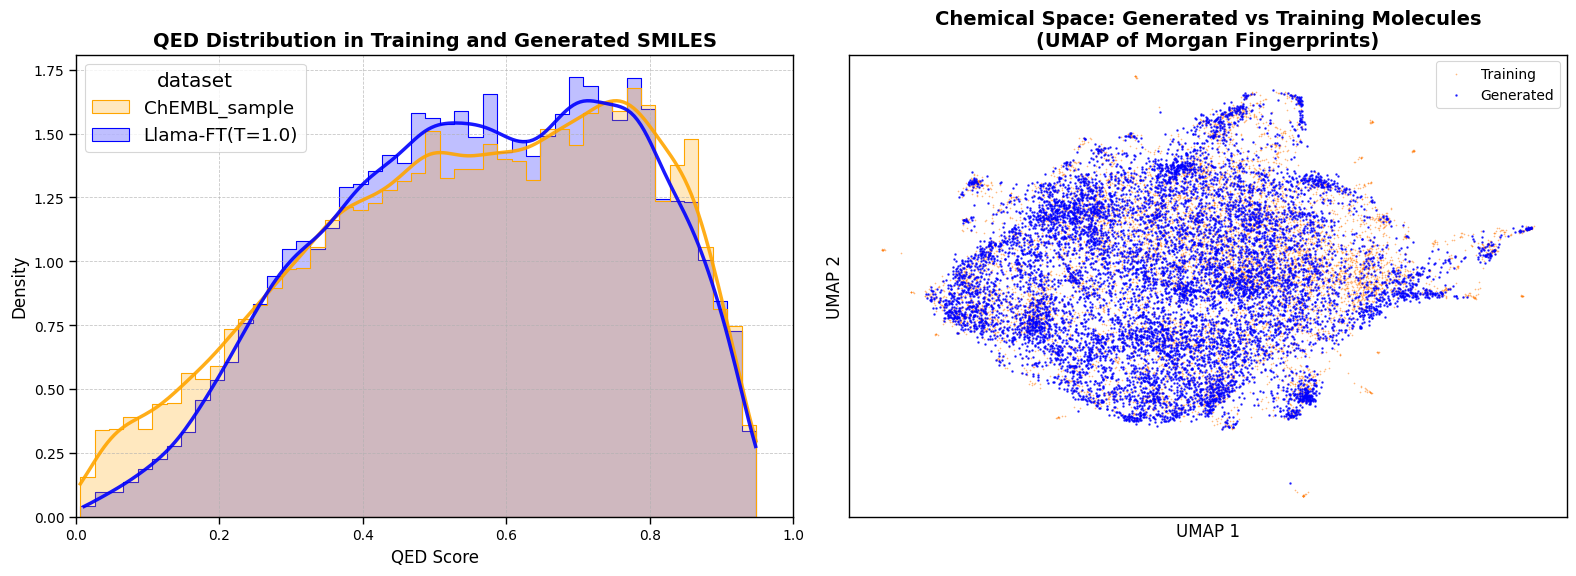

(<Figure size 1600x600 with 2 Axes>,
 (<Axes: title={'center': 'QED Distribution in Training and Generated SMILES'}, xlabel='QED Score', ylabel='Density'>,
  <Axes: title={'center': 'Chemical Space: Generated vs Training Molecules\n(UMAP of Morgan Fingerprints)'}, xlabel='UMAP 1', ylabel='UMAP 2'>))

In [12]:
create_combined_plots(df_filtered, embedding_clean, labels_clean, x_limits, prop='qed_default', save_path='figure-2.png')

In [13]:
def visualize_smiles_umap_density(embedding, labels, figsize=(12, 10), save_path=None):
    # Create visualization
    print("Creating visualization...")
    plt.figure(figsize=(15, 5))
    
    # Separate data
    train_mask = labels == 'Training'
    gen_mask = labels == 'Generated'
    
    # Calculate consistent limits based on all data
    x_min, x_max = embedding[:, 0].min(), embedding[:, 0].max()
    y_min, y_max = embedding[:, 1].min(), embedding[:, 1].max()
    
    # Add small padding (optional)
    x_padding = (x_max - x_min) * 0.02
    y_padding = (y_max - y_min) * 0.02
    x_min -= x_padding
    x_max += x_padding
    y_min -= y_padding
    y_max += y_padding
    
    # Plot 1: Training density
    plt.subplot(1, 3, 1)
    plt.scatter(embedding[train_mask, 0], embedding[train_mask, 1], 
               c='tab:orange', alpha=0.5, s=1)
    plt.title('ChEMBL Training Molecules', fontweight='bold')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    # Plot 2: Generated density  
    plt.subplot(1, 3, 2)
    plt.scatter(embedding[gen_mask, 0], embedding[gen_mask, 1], 
               c='blue', alpha=0.7, s=1)
    plt.title('SmileyLlama-Generated Molecules', fontweight='bold')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    
    # Plot 3: Combined
    plt.subplot(1, 3, 3)
    plt.scatter(embedding[train_mask, 0], embedding[train_mask, 1], 
               c='tab:orange', alpha=0.5, s=1, label='Training')
    plt.scatter(embedding[gen_mask, 0], embedding[gen_mask, 1], 
               c='blue', alpha=0.5, s=1, label='Generated')
    plt.title('Combined View', fontweight='bold')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    


Creating visualization...


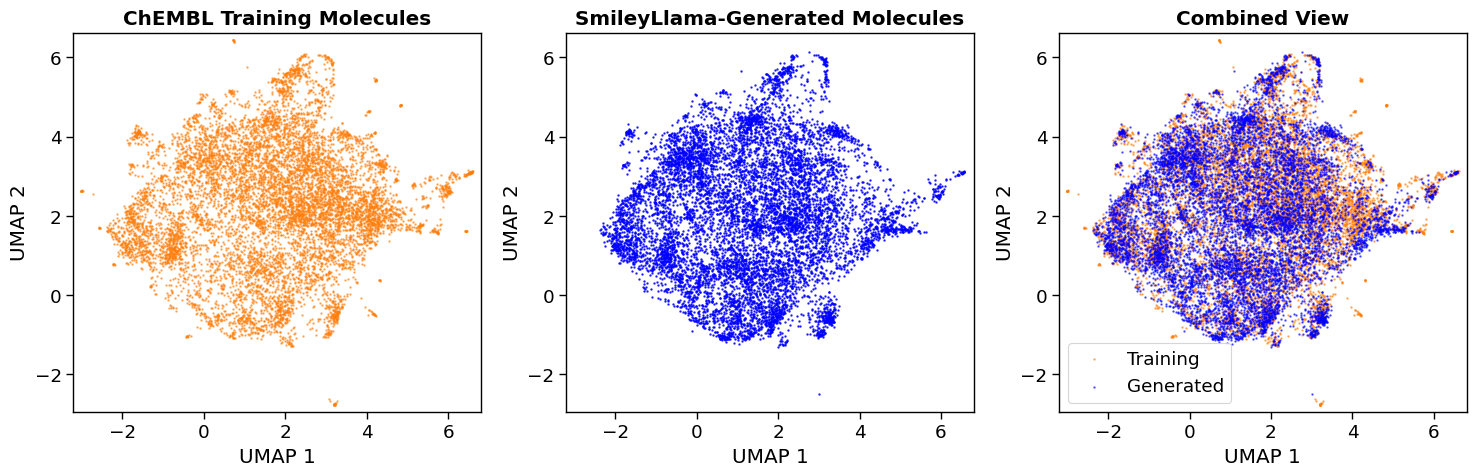

In [14]:
results = visualize_smiles_umap_density(
    embedding_clean,
    labels_clean,
    figsize=(8,6),
    save_path="density_umap_comparison.png"
)